# Mislabel Detection via TF-IDF + Out-of-Fold Probabilities

## Approach

Toxicity annotation is subjective. Crowd-sourced NLP label noise studies typically find **3–8%** mislabeling rates. We detect suspected mislabels by:

1. **Binary label** — collapse all 6 toxic sub-labels into `is_toxic` (1 if any label > 0, else 0)
2. **TF-IDF Features** — word unigrams/bigrams (100k features)
3. **5-Fold Cross-Validation** — train a single Logistic Regression on 4 folds, collect predicted probabilities on the held-out fold for every sample
4. **Out-of-Fold (OOF) Probabilities** — each sample gets a probability from a model that never trained on it → unbiased signal
5. **Flag outliers** — samples where the model is highly confident but disagrees with the given label:
   - **Suspected false negatives**: `is_toxic=0` but `p_oof ≥ 0.80` (model thinks it's toxic)
   - **Suspected false positives**: `is_toxic=1` but `p_oof ≤ 0.20` (model thinks it's clean)

### Why binary?
Collapsing 6 sub-labels into one `is_toxic` flag gives a single, clear target: is this comment toxic or not? This eliminates ambiguity from partial/overlapping multi-label assignments and makes the mislabel signal easier to interpret.

### Why these thresholds?
- A random disagreement at p=0.51 means nothing — the model is uncertain
- At p≥0.80 the model is *highly confident*, so the label is the more likely culprit

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('../data')
LABELS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Thresholds for flagging mislabels
HIGH_CONF = 0.80   # very likely mislabeled
MED_CONF  = 0.65   # possibly mislabeled (broader suspect list)
N_FOLDS   = 5
RANDOM_STATE = 42

## 1. Load Data

In [140]:
df = pd.read_csv(DATA_DIR / 'train.csv')

# Collapse all 6 sub-labels into a single binary target
df['is_toxic'] = (df[LABELS].sum(axis=1) > 0).astype(int)

print(f'Shape: {df.shape}')
print('\nOriginal sub-label distribution:')
label_counts = df[LABELS].sum()
label_pcts   = df[LABELS].mean() * 100
display(pd.DataFrame({'count': label_counts, 'pct': label_pcts.round(2)}))
print(f'\nBinary is_toxic: {df["is_toxic"].sum():,} toxic  ({df["is_toxic"].mean()*100:.2f}%)')

Shape: (159571, 9)

Original sub-label distribution:


,count,pct
toxic,15294,9.58
severe_toxic,1595,1.00
obscene,8449,5.29
threat,478,0.30
insult,7877,4.94
identity_hate,1405,0.88



Binary is_toxic: 16,225 toxic  (10.17%)


## 2. TF-IDF Features

Word unigrams + bigrams, 100k features, `sublinear_tf=True`.

In [115]:
texts = df['comment_text'].fillna('').values

print('Fitting word TF-IDF...')
word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=100_000,
    sublinear_tf=True,
    strip_accents='unicode',
    token_pattern=r'\w{2,}',
    min_df=3,
)
X = word_tfidf.fit_transform(texts)
print(f'Feature matrix shape: {X.shape}')

Fitting word TF-IDF...
Feature matrix shape: (159571, 100000)


## 3. Cross-Validated Out-of-Fold Probabilities

Train a **single binary classifier** on `is_toxic` (1 if any sub-label is set, else 0). Run 5-fold CV and store the held-out probability for every sample — this is the unbiased mislabel signal.

In [116]:
y   = df['is_toxic'].values
oof = np.zeros(len(y))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_aucs = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    clf = LogisticRegression(
        C=0.3,
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
    )
    clf.fit(X[train_idx], y[train_idx])
    oof[val_idx] = clf.predict_proba(X[val_idx])[:, 1]

    fold_auc = roc_auc_score(y[val_idx], oof[val_idx])
    fold_aucs.append(fold_auc)
    print(f'  Fold {fold+1}: AUC = {fold_auc:.4f}')

mean_auc = np.mean(fold_aucs)
print(f'\nis_toxic  OOF AUC = {mean_auc:.4f}')

  Fold 1: AUC = 0.9688
  Fold 2: AUC = 0.9652
  Fold 3: AUC = 0.9667
  Fold 4: AUC = 0.9672
  Fold 5: AUC = 0.9684

is_toxic  OOF AUC = 0.9673


In [117]:
df['p_oof'] = oof

## 4. Flag Suspected Mislabels

- **Suspected false negatives (FN)**: `is_toxic=0` but `p_oof ≥ HIGH_CONF` — model strongly predicts toxic, label says clean
- **Suspected false positives (FP)**: `is_toxic=1` but `p_oof ≤ 1 - HIGH_CONF` — model strongly predicts clean, label says toxic

In [118]:
y     = df['is_toxic'].values
p_oof = df['p_oof'].values

n_pos = int(y.sum())
n_neg = len(y) - n_pos

fn_mask_hi = (y == 0) & (p_oof >= HIGH_CONF)
fp_mask_hi = (y == 1) & (p_oof <= 1 - HIGH_CONF)

fn_mask_md = (y == 0) & (p_oof >= MED_CONF)
fp_mask_md = (y == 1) & (p_oof <= 1 - MED_CONF)

summary = pd.DataFrame([{
    'n_positive':       n_pos,
    'n_negative':       n_neg,
    'fn_hi':            int(fn_mask_hi.sum()),
    'fn_hi_pct_neg':    round(fn_mask_hi.sum() / n_neg * 100, 2),
    'fp_hi':            int(fp_mask_hi.sum()),
    'fp_hi_pct_pos':    round(fp_mask_hi.sum() / n_pos * 100, 2),
    'total_hi':         int(fn_mask_hi.sum() + fp_mask_hi.sum()),
    'total_hi_pct_all': round((fn_mask_hi.sum() + fp_mask_hi.sum()) / len(y) * 100, 2),
    'fn_md':            int(fn_mask_md.sum()),
    'fp_md':            int(fp_mask_md.sum()),
    'total_md':         int(fn_mask_md.sum() + fp_mask_md.sum()),
    'total_md_pct_all': round((fn_mask_md.sum() + fp_mask_md.sum()) / len(y) * 100, 2),
}], index=['is_toxic'])
display(summary)

,n_positive,n_negative,fn_hi,fn_hi_pct_neg,fp_hi,fp_hi_pct_pos,total_hi,total_hi_pct_all,fn_md,fp_md,total_md,total_md_pct_all
is_toxic,16225,143346,967,0.67,279,1.72,1246,0.78,3511,1111,4622,2.9


In [119]:
all_fn_hi       = fn_mask_hi
all_fp_hi       = fp_mask_hi
all_suspects_hi = all_fn_hi | all_fp_hi

print('=== HIGH-CONFIDENCE MISLABEL SUMMARY (threshold = {:.0%}) ==='.format(HIGH_CONF))
print(f'  Suspected false negatives (labeled 0, model says toxic): {all_fn_hi.sum():,}  ({all_fn_hi.mean()*100:.2f}% of all samples)')
print(f'  Suspected false positives (labeled 1, model says clean): {all_fp_hi.sum():,}  ({all_fp_hi.mean()*100:.2f}% of all samples)')
print(f'  Total unique flagged samples:                            {all_suspects_hi.sum():,}  ({all_suspects_hi.mean()*100:.2f}% of {len(df):,} training samples)')

=== HIGH-CONFIDENCE MISLABEL SUMMARY (threshold = 80%) ===
  Suspected false negatives (labeled 0, model says toxic): 967  (0.61% of all samples)
  Suspected false positives (labeled 1, model says clean): 279  (0.17% of all samples)
  Total unique flagged samples:                            1,246  (0.78% of 159,571 training samples)


## 5. Visualizations

### 5a. OOF Probability Distributions by True Label

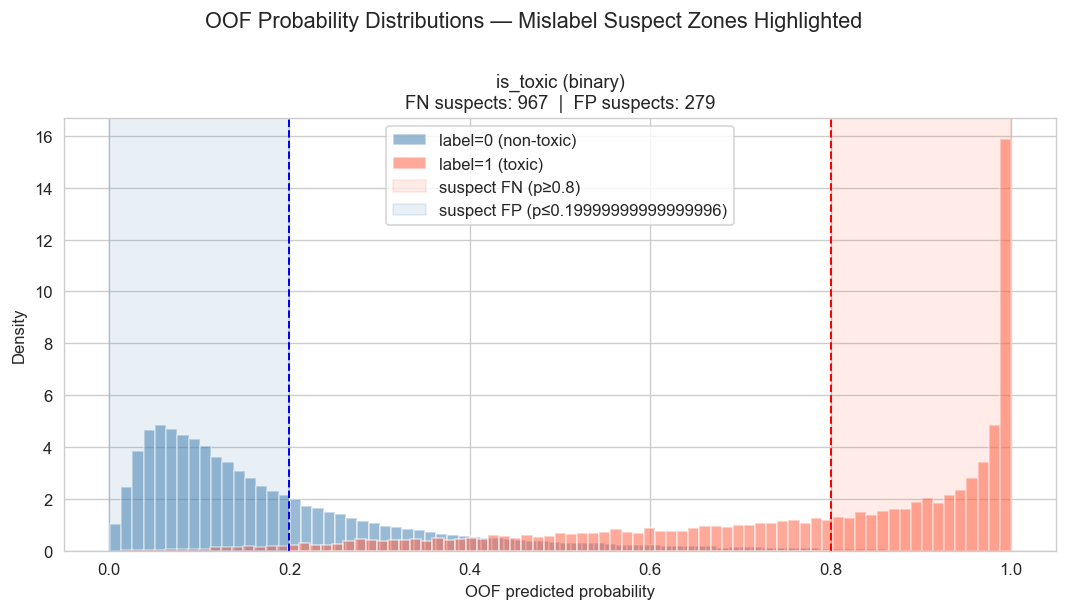

In [120]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(p_oof[y == 0], bins=80, alpha=0.55, color='steelblue', label='label=0 (non-toxic)', density=True)
ax.hist(p_oof[y == 1], bins=80, alpha=0.55, color='tomato',    label='label=1 (toxic)',     density=True)

ax.axvspan(HIGH_CONF, 1.0,     alpha=0.12, color='tomato',    label=f'suspect FN (p≥{HIGH_CONF})')
ax.axvspan(0.0, 1 - HIGH_CONF, alpha=0.12, color='steelblue', label=f'suspect FP (p≤{1-HIGH_CONF})')
ax.axvline(HIGH_CONF,     color='red',  linestyle='--', linewidth=1.2)
ax.axvline(1 - HIGH_CONF, color='blue', linestyle='--', linewidth=1.2)

ax.set_title(f'is_toxic (binary)\nFN suspects: {fn_mask_hi.sum():,}  |  FP suspects: {fp_mask_hi.sum():,}', fontsize=11)
ax.set_xlabel('OOF predicted probability')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('OOF Probability Distributions — Mislabel Suspect Zones Highlighted', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results_mislabel_distributions.png', bbox_inches='tight')
plt.show()

### 5b. Mislabel Counts by Label and Threshold

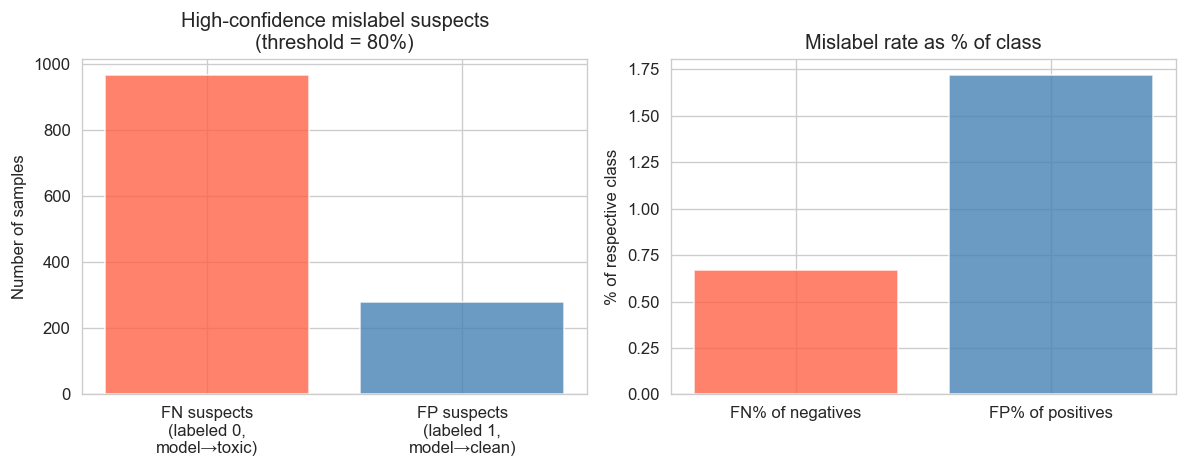

In [121]:
row = summary.loc['is_toxic']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ['FN suspects\n(labeled 0,\nmodel→toxic)', 'FP suspects\n(labeled 1,\nmodel→clean)'],
    [int(row['fn_hi']), int(row['fp_hi'])],
    color=['tomato', 'steelblue'], alpha=0.8
)
axes[0].set_ylabel('Number of samples')
axes[0].set_title(f'High-confidence mislabel suspects\n(threshold = {HIGH_CONF:.0%})')

axes[1].bar(
    ['FN% of negatives', 'FP% of positives'],
    [float(row['fn_hi_pct_neg']), float(row['fp_hi_pct_pos'])],
    color=['tomato', 'steelblue'], alpha=0.8
)
axes[1].set_ylabel('% of respective class')
axes[1].set_title('Mislabel rate as % of class')

plt.tight_layout()
plt.savefig('../results_mislabel_counts.png', bbox_inches='tight')
plt.show()

### 5c. Confidence Score Distribution of Suspects

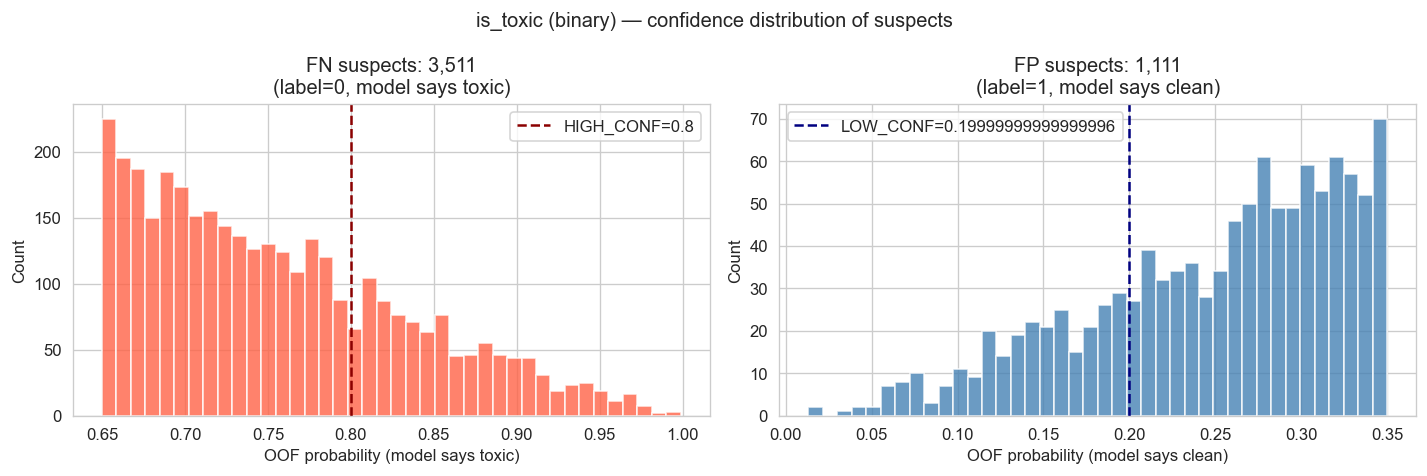

In [122]:
fn_suspects = df[(y == 0) & (p_oof >= MED_CONF)].copy()
fn_suspects['p_oof_val'] = p_oof[(y == 0) & (p_oof >= MED_CONF)]
fn_suspects = fn_suspects.sort_values('p_oof_val', ascending=False)

fp_suspects = df[(y == 1) & (p_oof <= 1 - MED_CONF)].copy()
fp_suspects['p_oof_val'] = p_oof[(y == 1) & (p_oof <= 1 - MED_CONF)]
fp_suspects = fp_suspects.sort_values('p_oof_val')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fn_suspects['p_oof_val'], bins=40, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(HIGH_CONF, color='darkred', linestyle='--', label=f'HIGH_CONF={HIGH_CONF}')
axes[0].set_xlabel('OOF probability (model says toxic)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'FN suspects: {len(fn_suspects):,}\n(label=0, model says toxic)')
axes[0].legend()

axes[1].hist(fp_suspects['p_oof_val'], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(1 - HIGH_CONF, color='navy', linestyle='--', label=f'LOW_CONF={1-HIGH_CONF}')
axes[1].set_xlabel('OOF probability (model says clean)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'FP suspects: {len(fp_suspects):,}\n(label=1, model says clean)')
axes[1].legend()

plt.suptitle('is_toxic (binary) — confidence distribution of suspects', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Inspect Examples

### 6a. Suspected False Negatives — toxic but labeled 0

In [123]:
fn_hi = df[(y == 0) & (p_oof >= HIGH_CONF)].copy()
fn_hi['p_oof_val'] = p_oof[(y == 0) & (p_oof >= HIGH_CONF)]
fn_hi = fn_hi.sort_values('p_oof_val', ascending=False)

print('Top 10 suspected false negatives (labeled 0 non-toxic, model very confident it is toxic):')
for _, row in fn_hi.head(10).iterrows():
    print(f'\n  p_oof={row["p_oof_val"]:.3f} | id={row["id"]}')
    print(f'  ["{row["comment_text"][:300]}"...' if len(row['comment_text']) > 300 else f'  "{row["comment_text"]}"')

Top 10 suspected false negatives (labeled 0 non-toxic, model very confident it is toxic):

  p_oof=0.999 | id=2224df415b3840b7
  "you are a manipulator."

  p_oof=0.993 | id=df5f289fe71f6e57
  "You are retarded
Learn to type like you're not five years old, MORON!"

  p_oof=0.992 | id=028aa892076cf0d1
  "You are a funney man."

  p_oof=0.988 | id=4459bdf71635b1c3
  "LOL PENIS! 

LOL!

I AM TALKING TO YOU SO THIS SHIT IS NOT VANDALISING!"

  p_oof=0.986 | id=17bdace76d2ecd70
  ["Some ratings from the VCHip 

1. The Power: TV-PG-L (hell, shit, pissed)

2. Just Set Up the Chairs: TV-PG-V (the Destroyer of World murders)

3. Caffeinated Concert Tickets: TV-PG-D (lady pecs = boobs, real reason people go to concerts is too see hot girls)

4. Death Punchies: TV-PG-V: (death kwon "...

  p_oof=0.981 | id=8ae74ff7c7534c32
  "oh wow a block im so scared. <sarcasm. stop getting all butt hurt bro. your threats don't faze me. you're just wasting your time getting all shook up over nothing"

  p_oof=

### 6b. Suspected False Positives — labeled toxic but model says clean

In [124]:
fp_hi = df[(y == 1) & (p_oof <= 1 - HIGH_CONF)].copy()
fp_hi['p_oof_val'] = p_oof[(y == 1) & (p_oof <= 1 - HIGH_CONF)]
fp_hi = fp_hi.sort_values('p_oof_val')

print('Top 10 suspected false positives (labeled 1 toxic, model very confident it is clean):')
for _, row in fp_hi.head(10).iterrows():
    print(f'\n  p_oof={row["p_oof_val"]:.3f} | id={row["id"]}')
    print(f'  ["{row["comment_text"][:300]}"...' if len(row['comment_text']) > 300 else f'  "{row["comment_text"]}"')

Top 10 suspected false positives (labeled 1 toxic, model very confident it is clean):

  p_oof=0.013 | id=f36374af17471824
  "THE FUKKING RETARDO RACISTO KANUCK"

  p_oof=0.020 | id=b6c222c3225bc8ae
  [""STOP DELETING MY ADDITION!  You, Muboshgu/Mephistophelian say:

Please do not use talk pages ... for general discussion of the topic. They are
for discussion related to improving the article. They are not to be used as a
forum or chat. If you continue to use talk pages as you do, you may be blocked"...

  p_oof=0.031 | id=bb5747668e181d81
  ["stupid bots deleting pics

I would like to ask a HUMAN to review the entry, and possibly add photos from the links I have provided. I cannot figure out how to do it myself.

Also, someone should either reprogram or shut down this BOT.

April 2008
 Welcome to Wikipedia. Although everyone is welcome t"...

  p_oof=0.041 | id=a490a89efba3c2b2
  [""

 First point - it was not only treated as mental illness, but as criminal activity.
 Second point - yo

## 7. Build Cleaned Dataset

Two strategies are available. Choose based on your use case:

| Strategy | What it does | When to use |
|---|---|---|
| **Drop** | Remove high-confidence suspects entirely | When you'd rather have less, cleaner data |
| **Relabel** | Flip label to match the OOF prediction | When you want to preserve dataset size |

In [125]:
STRATEGY = 'drop'   # change to 'relabel' to flip labels instead
THRESHOLD = HIGH_CONF

df_clean = df[['id', 'comment_text', 'is_toxic'] + LABELS].copy()

if STRATEGY == 'relabel':
    df_clean.loc[fn_mask_hi, 'is_toxic'] = 1
    df_clean.loc[fp_mask_hi, 'is_toxic'] = 0
    print(f'Relabeled {fn_mask_hi.sum():,} FN + {fp_mask_hi.sum():,} FP')
else:
    df_clean = df_clean[~all_suspects_hi].reset_index(drop=True)
    print(f'Dropped {all_suspects_hi.sum():,} samples ({all_suspects_hi.mean()*100:.2f}%).')
    print(f'Cleaned dataset size: {len(df_clean):,}  (was {len(df):,})')

print('\nNew label distribution:')
display(pd.DataFrame(
    {'count': [df_clean['is_toxic'].sum()], 'pct': [round(df_clean['is_toxic'].mean() * 100, 2)]},
    index=['is_toxic']
))

Dropped 1,246 samples (0.78%).
Cleaned dataset size: 158,325  (was 159,571)

New label distribution:


,count,pct
is_toxic,15946,10.07


In [126]:
out_csv     = DATA_DIR / 'train_cleaned.csv'
out_parquet = DATA_DIR / 'train_cleaned.parquet'
df_clean.to_csv(out_csv, index=False)
df_clean.to_parquet(out_parquet, index=False)
print(f'Saved cleaned training data to {out_csv} and {out_parquet}')
print(f'Columns: {list(df_clean.columns)}')

Saved cleaned training data to ../data/train_cleaned.csv and ../data/train_cleaned.parquet
Columns: ['id', 'comment_text', 'is_toxic', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


## 8. Sanity Check — Does Cleaning Help?

Retrain on cleaned data with a simple 80/20 hold-out and compare AUC to the full noisy dataset.

In [127]:
from sklearn.model_selection import train_test_split

def quick_auc(X_train, y_train, X_val, y_val):
    clf = LogisticRegression(C=0.3, solver='lbfgs', max_iter=1000, class_weight='balanced')
    clf.fit(X_train, y_train)
    return roc_auc_score(y_val, clf.predict_proba(X_val)[:, 1])

y_full = df['is_toxic'].values
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

auc_noisy = quick_auc(X[train_idx], y_full[train_idx], X[val_idx], y_full[val_idx])

if STRATEGY == 'drop':
    clean_train_mask = train_idx[~all_suspects_hi[train_idx]]
    auc_clean = quick_auc(X[clean_train_mask], y_full[clean_train_mask], X[val_idx], y_full[val_idx])
else:
    auc_clean = quick_auc(X[train_idx], df_clean['is_toxic'].values[train_idx], X[val_idx], y_full[val_idx])

print(f'[is_toxic]  Noisy AUC = {auc_noisy:.4f}  |  Cleaned AUC = {auc_clean:.4f}  |  Delta = {auc_clean - auc_noisy:+.4f}')

[is_toxic]  Noisy AUC = 0.9675  |  Cleaned AUC = 0.9656  |  Delta = -0.0019


## 9. Summary

This cell prints a final human-readable report.

In [128]:
row = summary.loc['is_toxic']

print('=' * 65)
print('MISLABEL DETECTION REPORT')
print(f'Method:    TF-IDF (word 1-2g) + LogReg, {N_FOLDS}-fold CV')
print(f'Threshold: p ≥ {HIGH_CONF} (high-confidence) / p ≥ {MED_CONF} (medium-confidence)')
print(f'Dataset:   {len(df):,} training samples')
print(f'Label:     is_toxic (binary — any of {LABELS} > 0)')
print('=' * 65)
print()
print(f'{"Label":<18} {"FN suspects":>12} {"FN%neg":>8} {"FP suspects":>12} {"FP%pos":>8} {"Total":>8} {"Total%":>7}')
print('-' * 75)
print(f'{"is_toxic":<18} {int(row["fn_hi"]):>12,} {float(row["fn_hi_pct_neg"]):>7.2f}% {int(row["fp_hi"]):>12,} {float(row["fp_hi_pct_pos"]):>7.2f}% {int(row["total_hi"]):>8,} {float(row["total_hi_pct_all"]):>6.2f}%')
print('-' * 75)
print()
print(f'Unique samples flagged: {all_suspects_hi.sum():,}  ({all_suspects_hi.mean()*100:.2f}% of dataset)')
print()
print('Notes:')
print('  - "FN suspects" = labeled 0 (clean) but model p >= threshold  →  possibly missed toxic')
print('  - "FP suspects" = labeled 1 (toxic) but model p <= 1-threshold →  possibly mislabeled toxic')
print('=' * 65)

MISLABEL DETECTION REPORT
Method:    TF-IDF (word 1-2g) + LogReg, 5-fold CV
Threshold: p ≥ 0.8 (high-confidence) / p ≥ 0.65 (medium-confidence)
Dataset:   159,571 training samples
Label:     is_toxic (binary — any of ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'] > 0)

Label               FN suspects   FN%neg  FP suspects   FP%pos    Total  Total%
---------------------------------------------------------------------------
is_toxic                    967    0.67%          279    1.72%    1,246   0.78%
---------------------------------------------------------------------------

Unique samples flagged: 1,246  (0.78% of dataset)

Notes:
  - "FN suspects" = labeled 0 (clean) but model p >= threshold  →  possibly missed toxic
  - "FP suspects" = labeled 1 (toxic) but model p <= 1-threshold →  possibly mislabeled toxic


## 10. Aggregated Summary Tables

In [129]:
dropped_ids = set(df['id']) - set(df_clean['id'])
dropped     = df[df['id'].isin(dropped_ids)]
n_orig      = len(df)
n_clean     = len(df_clean)
n_dropped   = n_orig - n_clean

tbl1 = pd.DataFrame({
    'Rows':          [f'{n_orig:,}',   f'{n_clean:,}',   f'{n_dropped:,}'],
    '% of original': [f'{100.0:.2f}%', f'{n_clean/n_orig*100:.2f}%', f'{n_dropped/n_orig*100:.2f}%'],
}, index=['Original', 'After cleaning', 'Removed'])

print(f'Strategy: {STRATEGY}  |  Threshold: p ≥ {THRESHOLD}\n')
print('Table 1 — Dataset Summary')
display(tbl1)

Strategy: drop  |  Threshold: p ≥ 0.8

Table 1 — Dataset Summary


,Rows,% of original
Original,"159,571",100.00%
After cleaning,"158,325",99.22%
Removed,"1,246",0.78%


In [130]:
row = summary.loc['is_toxic']
tbl2 = pd.DataFrame([{
    'Positives':      int(row['n_positive']),
    'Negatives':      int(row['n_negative']),
    'FN suspects':    int(row['fn_hi']),
    'FN % of neg':    float(row['fn_hi_pct_neg']),
    'FP suspects':    int(row['fp_hi']),
    'FP % of pos':    float(row['fp_hi_pct_pos']),
    'Total suspects': int(row['total_hi']),
    'Total % of all': float(row['total_hi_pct_all']),
}], index=['is_toxic'])

print(f'Table 2 — High-confidence Mislabel Suspects (threshold = {HIGH_CONF:.0%})')
display(tbl2)

Table 2 — High-confidence Mislabel Suspects (threshold = 80%)


,Positives,Negatives,FN suspects,FN % of neg,FP suspects,FP % of pos,Total suspects,Total % of all
is_toxic,16225,143346,967,0.67,279,1.72,1246,0.78


In [131]:
op = int(df['is_toxic'].sum())
cp = int(df_clean['is_toxic'].sum())
dp = int(dropped['is_toxic'].sum()) if len(dropped) > 0 else 0

tbl3 = pd.DataFrame([{
    'Orig positives':        op,
    'Clean positives':       cp,
    'Positives removed':     dp,
    'Removed % of orig pos': f'{dp/op*100:.1f}%' if op > 0 else '—',
    'Orig rate':             f'{op/n_orig*100:.2f}%',
    'Clean rate':            f'{cp/n_clean*100:.2f}%',
    'Rate delta':            f'{cp/n_clean*100 - op/n_orig*100:+.2f}%',
}], index=['is_toxic'])

print('Table 3 — Class Balance Impact After Cleaning')
display(tbl3)

if len(dropped) > 0:
    is_toxic_dropped = dropped['is_toxic']
    tbl4 = pd.DataFrame({
        'Count': [int((is_toxic_dropped == 0).sum()), int((is_toxic_dropped == 1).sum())],
        '% of dropped': [
            f'{(is_toxic_dropped == 0).mean()*100:.1f}%',
            f'{(is_toxic_dropped == 1).mean()*100:.1f}%',
        ],
    }, index=['Labeled non-toxic (FN suspects)', 'Labeled toxic (FP suspects)'])
    print('\nTable 4 — Label Distribution in Dropped Rows')
    display(tbl4)
else:
    print('\nNo rows dropped (strategy = relabel).')

Table 3 — Class Balance Impact After Cleaning


,Orig positives,Clean positives,Positives removed,Removed % of orig pos,Orig rate,Clean rate,Rate delta
is_toxic,16225,15946,279,1.7%,10.17%,10.07%,-0.10%



Table 4 — Label Distribution in Dropped Rows


,Count,% of dropped
Labeled non-toxic (FN suspects),967,77.6%
Labeled toxic (FP suspects),279,22.4%


In [132]:
records = []
for _, row in dropped.iterrows():
    p = row['p_oof']
    if row['is_toxic'] == 0 and p >= THRESHOLD:
        flag = f'is_toxic=FN(p={p:.2f})'
    elif row['is_toxic'] == 1 and p <= 1 - THRESHOLD:
        flag = f'is_toxic=FP(p={p:.2f})'
    else:
        flag = ''
    records.append({
        'id':           row['id'],
        'comment_text': row['comment_text'],
        'is_toxic':     int(row['is_toxic']),
        'p_is_toxic':   round(p, 3),
        'flags':        flag,
    })

dropped_train_full = pd.DataFrame(records)
# label_is_toxic = 1 if model thinks comment is toxic (FN: labeled 0, model says toxic)
# label_is_toxic = 0 if model thinks comment is clean (FP: labeled 1, model says clean)
dropped_train_full['label_is_toxic'] = dropped_train_full['flags'].str.contains('FN').astype(int)

print(f'Train dropped rows prepared: {len(dropped_train_full):,}')
print(f'label_is_toxic distribution:\n{dropped_train_full["label_is_toxic"].value_counts()}')

Train dropped rows prepared: 1,246
label_is_toxic distribution:
label_is_toxic
1    967
0    279
Name: count, dtype: int64


## 11. Test Set Mislabel Detection

The test set has **153,164** rows but only **63,978** carry real labels (the rest are `-1`, withheld from Kaggle scoring). We can still check those 63k for mislabels.

**Key difference from training:** we can't do OOF on test data — there's no held-out fold. Instead we train on the **full training set** and predict on the labeled test rows. Because the model never saw test data, the disagreement signal is still unbiased (just slightly less so than OOF, since the model used all training samples rather than 80%).

In [133]:
test_text   = pd.read_parquet(DATA_DIR / 'test.parquet')
test_labels = pd.read_parquet(DATA_DIR / 'test_labels.parquet')

df_test = test_text.merge(test_labels, on='id')
df_test = df_test[df_test['toxic'] != -1].reset_index(drop=True)

# Collapse sub-labels into binary is_toxic
df_test['is_toxic'] = (df_test[LABELS].sum(axis=1) > 0).astype(int)

print(f'Labeled test rows: {len(df_test):,}  (of {len(test_text):,} total)')
print(f'\nis_toxic distribution:')
display(pd.DataFrame(
    {'count': [df_test['is_toxic'].sum()], 'pct': [round(df_test['is_toxic'].mean() * 100, 2)]},
    index=['is_toxic']
))

Labeled test rows: 63,978  (of 153,164 total)

is_toxic distribution:


,count,pct
is_toxic,6243,9.76


In [134]:
# Transform test text with the already-fitted word TF-IDF (no refit — avoids data leakage)
X_test = word_tfidf.transform(df_test['comment_text'].fillna('').values)
print(f'Test feature matrix: {X_test.shape}')

Test feature matrix: (63978, 100000)


In [135]:
clf = LogisticRegression(C=0.3, solver='lbfgs', max_iter=1000, class_weight='balanced')
clf.fit(X, df['is_toxic'].values)
df_test['p_is_toxic'] = clf.predict_proba(X_test)[:, 1]
print('Trained on full training set, predicted on labeled test rows.')

Trained on full training set, predicted on labeled test rows.


### 11b. Flag and Drop Suspected Mislabels in Test Set

In [136]:
y_t   = df_test['is_toxic'].values
p_t   = df_test['p_is_toxic'].values
n_pos_t = int(y_t.sum())
n_neg_t = len(y_t) - n_pos_t

test_fn = (y_t == 0) & (p_t >= THRESHOLD)
test_fp = (y_t == 1) & (p_t <= 1 - THRESHOLD)
test_suspects = test_fn | test_fp

print(f'=== Test Set Mislabel Summary (threshold = {THRESHOLD}) ===')
print(f'  Suspected false negatives: {test_fn.sum():,}  ({test_fn.mean()*100:.2f}%)')
print(f'  Suspected false positives: {test_fp.sum():,}  ({test_fp.mean()*100:.2f}%)')
print(f'  Total unique flagged:       {test_suspects.sum():,}  ({test_suspects.mean()*100:.2f}% of {len(df_test):,} labeled test rows)')

display(pd.DataFrame([{
    'n_positive':  n_pos_t,
    'n_negative':  n_neg_t,
    'FN suspects': int(test_fn.sum()),
    'FN % of neg': round(test_fn.sum() / n_neg_t * 100, 2),
    'FP suspects': int(test_fp.sum()),
    'FP % of pos': round(test_fp.sum() / n_pos_t * 100, 2),
    'Total':       int(test_suspects.sum()),
}], index=['is_toxic']))

=== Test Set Mislabel Summary (threshold = 0.8) ===
  Suspected false negatives: 2,054  (3.21%)
  Suspected false positives: 79  (0.12%)
  Total unique flagged:       2,133  (3.33% of 63,978 labeled test rows)


,n_positive,n_negative,FN suspects,FN % of neg,FP suspects,FP % of pos,Total
is_toxic,6243,57735,2054,3.56,79,1.27,2133


In [137]:
flagged_test_ids = set(df_test['id'][test_suspects])

df_test_labels_clean = df_test[['id', 'comment_text', 'is_toxic'] + LABELS][~test_suspects].reset_index(drop=True)
df_test_full_clean   = test_text[~test_text['id'].isin(flagged_test_ids)].reset_index(drop=True)

print(f'Dropped {test_suspects.sum():,} flagged rows ({test_suspects.mean()*100:.2f}% of labeled test rows)')
print(f'  test_labels_cleaned : {len(df_test_labels_clean):,}  (was {len(df_test):,} labeled rows)')
print(f'  test_cleaned        : {len(df_test_full_clean):,}  (was {len(test_text):,} total rows)')

df_test_labels_clean.to_csv(DATA_DIR / 'test_labels_cleaned.csv', index=False)
df_test_labels_clean.to_parquet(DATA_DIR / 'test_labels_cleaned.parquet', index=False)
df_test_full_clean.to_csv(DATA_DIR / 'test_cleaned.csv', index=False)
df_test_full_clean.to_parquet(DATA_DIR / 'test_cleaned.parquet', index=False)

print(f'\nSaved → {DATA_DIR / "test_labels_cleaned.csv"} + .parquet')
print(f'Saved → {DATA_DIR / "test_cleaned.csv"} + .parquet')
print(f'test_labels_cleaned columns: {list(df_test_labels_clean.columns)}')

Dropped 2,133 flagged rows (3.33% of labeled test rows)
  test_labels_cleaned : 61,845  (was 63,978 labeled rows)
  test_cleaned        : 151,031  (was 153,164 total rows)

Saved → ../data/test_labels_cleaned.csv + .parquet
Saved → ../data/test_cleaned.csv + .parquet
test_labels_cleaned columns: ['id', 'comment_text', 'is_toxic', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


### 11c. Export Dropped Rows to CSV

In [138]:
test_dropped = df_test[test_suspects].copy().reset_index(drop=True)
dropped_test_full = test_dropped[['id', 'comment_text', 'is_toxic']].copy()
dropped_test_full['p_is_toxic'] = test_dropped['p_is_toxic'].round(3).values

flags_col = []
for _, row in test_dropped.iterrows():
    p = row['p_is_toxic']
    if row['is_toxic'] == 0 and p >= THRESHOLD:
        flags_col.append(f'is_toxic=FN(p={p:.2f})')
    elif row['is_toxic'] == 1 and p <= 1 - THRESHOLD:
        flags_col.append(f'is_toxic=FP(p={p:.2f})')
    else:
        flags_col.append('')

dropped_test_full['flags'] = flags_col
# label_is_toxic = 1 if model thinks comment is toxic (FN: labeled 0, model says toxic)
# label_is_toxic = 0 if model thinks comment is clean (FP: labeled 1, model says clean)
dropped_test_full['label_is_toxic'] = dropped_test_full['flags'].str.contains('FN').astype(int)

out_path = DATA_DIR / 'dropped_rows.csv'
with open(out_path, 'w') as f:
    dropped_train_full.to_csv(f, index=False)
    dropped_test_full.to_csv(f, index=False)

print(f'Exported to {out_path}')
print(f'  Sheet "train_dropped"       : {len(dropped_train_full):,} rows')
print(f'  Sheet "test_labels_dropped" : {len(dropped_test_full):,} rows')
print(f'\nlabel_is_toxic distribution (test dropped):')
print(dropped_test_full['label_is_toxic'].value_counts())

Exported to ../data/dropped_rows.csv
  Sheet "train_dropped"       : 1,246 rows
  Sheet "test_labels_dropped" : 2,133 rows

label_is_toxic distribution (test dropped):
label_is_toxic
1    2054
0      79
Name: count, dtype: int64
